# QPINN for a parametric-volatility HJB PDE in portfolio optimization


### Import packages

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import LogLocator, FuncFormatter
import torch
import torch.nn as nn
from torch.autograd import grad
import pennylane as qml
try:
    import torch_optimizer as optim
    optimizer_name = "Lamb"
except ModuleNotFoundError:
    optim = torch.optim
    optimizer_name = "Adam"
    print("torch_optimizer is not installed; falling back to torch.optim.Adam.")
import numpy as np
from matplotlib import rcParams

### Train QPINN, PINN, and Counterpart PINN

In [21]:
# ===============================
# Parametric-volatility Merton HJB benchmark
# ===============================
r = 0.02
T = 1.0
mu = 0.0219
gamma = 0.95
sigma_min = 0.15
sigma_max = 0.25
sigma_ref = 0.20


def k_of_sigma(s):
    return -gamma * r + 0.5 * (gamma / (gamma - 1)) * ((mu - r) / s) ** 2


def exact_solution(t, x, s):
    return torch.exp(-k_of_sigma(s) * (T - t)) * x**gamma / gamma


def k_of_sigma_np(s):
    return -gamma * r + 0.5 * (gamma / (gamma - 1)) * ((mu - r) / s) ** 2


def exact_solution_np(t, x, s):
    return np.exp(-k_of_sigma_np(s) * (T - t)) * x**gamma / gamma


x_layer1 = 2
x_layer2 = 3
t_layer1 = 1
t_layer2 = 2
s_layer1 = 3
s_layer2 = 4
scale = 5
output_shift = 1
phase_init_center = 1e-6
phase_init_std = 2 * torch.pi
theta_init_std = 0.0

epochs = 2000
entangler_train_start_epoch = 500
initial_lr = 5e-3
lr_decay = 0.995
min_lr = 1e-7
Trainable_entangle_begin = False # added entangling layer is trainable in the beginning, or not

warm_start_candidates = 8
warm_start_epochs = 70
pinn_layers = [3,10,10,10,10,10,1]

mps_built = torch.backends.mps.is_built()
mps_available = torch.backends.mps.is_available()
torch_device = torch.device("mps" if mps_available else "cpu")
torch_dtype = torch.float32 if torch_device.type == "mps" else torch.float64
torch.set_default_dtype(torch_dtype)
print(f"Using torch device={torch_device}, dtype={torch_dtype}")
if torch_device.type == "mps":
    print("MPS acceleration enabled: models and torch quantum circuits will run on Apple Metal (mps).")
else:
    print(f"MPS acceleration not available; using CPU fallback. is_built={mps_built}, is_available={mps_available}")

# ===============================
# Run seed
# ===============================
results_root = Path("results_parametric_volatility")
base_seed = 51
manual_run_index = None  # set to an integer to fix the first run/seed
num_runs = 1
seed_step = 100
save_results = True
overwrite_run = True
print_every = 1


def next_available_run_index(root=results_root):
    root.mkdir(parents=True, exist_ok=True)
    run_indices = []
    for path in root.glob("run_*"):
        if path.is_dir():
            try:
                run_indices.append(int(path.name.split("_", 1)[1]))
            except (IndexError, ValueError):
                pass
    return max(run_indices, default=-1) + 1


def set_global_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def set_run_seed(run_idx, base=base_seed, step=seed_step):
    seed = int(base + step * run_idx)
    set_global_seed(seed)
    return seed


def get_run_indices():
    start_index = next_available_run_index() if manual_run_index is None else int(manual_run_index)
    return list(range(start_index, start_index + num_runs))


run_indices = get_run_indices()
print(f"Configured run indices: {run_indices}")
n_wires = 8
dev = qml.device("default.qubit", wires=n_wires)

# ===============================
# Sampling + utility
# ===============================
def sample_uniform(n, low, high):
    return low + (high - low) * torch.rand((n, 1), dtype=torch_dtype, device=torch_device)


def sample_collocation(n):
    t = sample_uniform(n, 0.01, 0.99)
    x = sample_uniform(n, 0.01, 0.99)
    s = sample_uniform(n, sigma_min, sigma_max)
    return t, x, s


def sample_terminal_boundary(n):
    t = torch.full((n, 1), T, dtype=torch_dtype, device=torch_device)
    x = sample_uniform(n, 0.01, 0.99)
    s = sample_uniform(n, sigma_min, sigma_max)
    return t, x, s


def sample_wealth_boundary(n):
    t = sample_uniform(n, 0.01, 0.99)
    x = torch.ones((n, 1), dtype=torch_dtype, device=torch_device)
    s = sample_uniform(n, sigma_min, sigma_max)
    return t, x, s


def U(x):
    return x**gamma / gamma

# ===============================
# Quantum circuit
# ===============================
def S(z, wire):
    qml.RX(-2 * torch.acos(z), wires=wire)


def U_qsp(phases, z, wire):
    qml.RZ(phases[0], wires=wire)
    for phi in phases[1:]:
        S(z, wire)
        qml.RZ(phi, wires=wire)


def W_rank_term(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    qml.PauliX(wires=2)
    qml.ctrl(U_qsp, control=2)(ph_x1, x, 3)
    qml.PauliX(wires=2)
    qml.ctrl(U_qsp, control=2)(ph_x2, x, 3)

    qml.PauliX(wires=4)
    qml.ctrl(U_qsp, control=4)(ph_t1, t, 5)
    qml.PauliX(wires=4)
    qml.ctrl(U_qsp, control=4)(ph_t2, t, 5)

    qml.PauliX(wires=6)
    qml.ctrl(U_qsp, control=6)(ph_s1, s, 7)
    qml.PauliX(wires=6)
    qml.ctrl(U_qsp, control=6)(ph_s2, s, 7)


def W_td_rank2(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    qml.PauliX(wires=1)
    qml.ctrl(W_rank_term, control=1)(t, x, s, ph_x1[0], ph_x2[0], ph_t1[0], ph_t2[0], ph_s1[0], ph_s2[0])
    qml.PauliX(wires=1)
    qml.ctrl(W_rank_term, control=1)(t, x, s, ph_x1[1], ph_x2[1], ph_t1[1], ph_t2[1], ph_s1[1], ph_s2[1])


def W_lcu(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2, theta_list):
    W_td_rank2(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2)
    qml.IsingZZ(theta_list[0], wires=[5, 7])
    qml.IsingZZ(theta_list[1], wires=[5, 6])
    qml.IsingZZ(theta_list[2], wires=[4, 7])
    qml.IsingZZ(theta_list[3], wires=[4, 6])


def W_lcu_QI(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    W_td_rank2(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2)


def prepare_td_input_state():
    for w in range(n_wires):
        qml.Hadamard(wires=w)


@qml.qnode(dev, interface="torch", diff_method="backprop")
def f_Wp_qml(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2, theta_list):
    prepare_td_input_state()
    qml.ctrl(W_lcu, control=0)(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2, theta_list)
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(wires=0))


@qml.qnode(dev, interface="torch", diff_method="backprop")
def f_Wp_QI_qml(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    prepare_td_input_state()
    qml.ctrl(W_lcu_QI, control=0)(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2)
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(wires=0))

# ===============================
# Fast batched torch implementation using the equivalent target-register overlap
# ===============================
_target_index_cache = {}
_target_sign_cache = {}
target_n_wires = n_wires - 1
target_dim = 2 ** target_n_wires


def _device_key(device):
    device = torch.device(device)
    return (device.type, device.index)


def _target_wire_mask(wire):
    return 1 << (target_n_wires - 1 - wire)


def _target_x_perm(target, device):
    key = ("target_x_perm", target, _device_key(device))
    if key not in _target_index_cache:
        mask = _target_wire_mask(target)
        _target_index_cache[key] = torch.tensor(
            [idx ^ mask for idx in range(target_dim)], dtype=torch.long, device=device
        )
    return _target_index_cache[key]


def _target_control_mask(controls, device):
    key = ("target_control_mask", tuple(controls), _device_key(device))
    if key not in _target_index_cache:
        values = [all(idx & _target_wire_mask(control) for control in controls) for idx in range(target_dim)]
        _target_index_cache[key] = torch.tensor(values, dtype=torch.bool, device=device).unsqueeze(0)
    return _target_index_cache[key]


def _target_controlled_pairs(target, controls, device):
    key = ("target_pairs", target, tuple(controls), _device_key(device))
    if key not in _target_index_cache:
        idx0, idx1 = [], []
        target_mask = _target_wire_mask(target)
        for idx in range(target_dim):
            if idx & target_mask:
                continue
            if all(idx & _target_wire_mask(control) for control in controls):
                idx0.append(idx)
                idx1.append(idx | target_mask)
        _target_index_cache[key] = (
            torch.tensor(idx0, dtype=torch.long, device=device),
            torch.tensor(idx1, dtype=torch.long, device=device),
        )
    return _target_index_cache[key]


def _target_rz_imag_sign(target, controls, device, dtype):
    key = ("target_rz_sign", target, tuple(controls), _device_key(device), dtype)
    if key not in _target_sign_cache:
        values = []
        target_mask = _target_wire_mask(target)
        for idx in range(target_dim):
            active = all(idx & _target_wire_mask(control) for control in controls)
            if not active:
                values.append(0.0)
            else:
                values.append(1.0 if idx & target_mask else -1.0)
        _target_sign_cache[key] = torch.tensor(values, dtype=dtype, device=device).unsqueeze(0)
    return _target_sign_cache[key]


def _target_isingzz_imag_sign(wires, device, dtype):
    key = ("target_isingzz_sign", tuple(wires), _device_key(device), dtype)
    if key not in _target_sign_cache:
        masks = [_target_wire_mask(wire) for wire in wires]
        values = []
        for idx in range(target_dim):
            same_parity = bool(idx & masks[0]) == bool(idx & masks[1])
            values.append(-1.0 if same_parity else 1.0)
        _target_sign_cache[key] = torch.tensor(values, dtype=dtype, device=device).unsqueeze(0)
    return _target_sign_cache[key]


def _to_reference_tensor(value, reference):
    if torch.is_tensor(value):
        return value.to(device=reference.device, dtype=reference.dtype)
    return torch.tensor(value, dtype=reference.dtype, device=reference.device)


def _prepare_circuit_batch(t, x, s, reference):
    t = _to_reference_tensor(t, reference)
    x = _to_reference_tensor(x, reference)
    s = _to_reference_tensor(s, reference)
    t, x, s = torch.broadcast_tensors(t, x, s)
    output_shape = t.shape
    return t.reshape(-1), x.reshape(-1), s.reshape(-1), output_shape


def _rank_state_amplitudes(reference):
    return torch.full((1, target_dim), target_dim ** -0.5, dtype=reference.dtype, device=reference.device)


def _init_target_rank_state(batch_size, reference):
    state_r = _rank_state_amplitudes(reference).repeat(batch_size, 1)
    state_i = torch.zeros_like(state_r)
    return state_r, state_i


def _complex_mul(real, imag, factor_r, factor_i):
    return real * factor_r - imag * factor_i, imag * factor_r + real * factor_i


def _apply_target_x(state_r, state_i, target):
    perm = _target_x_perm(target, state_r.device)
    return state_r[:, perm], state_i[:, perm]


def _apply_target_controlled_rz(state_r, state_i, controls, target, phase):
    active = _target_control_mask(controls, state_r.device)
    imag_sign = _target_rz_imag_sign(target, controls, state_r.device, state_r.dtype)
    cos_half = torch.cos(phase / 2)
    sin_half = torch.sin(phase / 2)
    one = torch.ones((), dtype=state_r.dtype, device=state_r.device)
    factor_r = torch.where(active, cos_half, one)
    factor_i = sin_half * imag_sign
    return _complex_mul(state_r, state_i, factor_r, factor_i)


def _apply_target_controlled_rx_s(state_r, state_i, controls, target, z):
    idx0, idx1 = _target_controlled_pairs(target, controls, state_r.device)
    if idx0.numel() == 0:
        return state_r, state_i
    z = z.reshape(-1, 1)
    cos_half = z
    sin_half = -torch.sqrt(torch.clamp(1 - z.square(), min=0.0))
    factor_i = -sin_half
    r0, i0 = state_r[:, idx0], state_i[:, idx0]
    r1, i1 = state_r[:, idx1], state_i[:, idx1]
    off_r1, off_i1 = _complex_mul(r1, i1, 0.0, factor_i)
    off_r0, off_i0 = _complex_mul(r0, i0, 0.0, factor_i)
    new_r, new_i = state_r.clone(), state_i.clone()
    new_r[:, idx0], new_i[:, idx0] = cos_half * r0 + off_r1, cos_half * i0 + off_i1
    new_r[:, idx1], new_i[:, idx1] = off_r0 + cos_half * r1, off_i0 + cos_half * i1
    return new_r, new_i


def _apply_target_u_qsp(state_r, state_i, controls, target, phases, z):
    state_r, state_i = _apply_target_controlled_rz(state_r, state_i, controls, target, phases[0])
    for phase in phases[1:]:
        state_r, state_i = _apply_target_controlled_rx_s(state_r, state_i, controls, target, z)
        state_r, state_i = _apply_target_controlled_rz(state_r, state_i, controls, target, phase)
    return state_r, state_i


def _apply_target_isingzz(state_r, state_i, wires, theta):
    imag_sign = _target_isingzz_imag_sign(wires, state_r.device, state_r.dtype)
    cos_half = torch.cos(theta / 2)
    sin_half = torch.sin(theta / 2)
    return _complex_mul(state_r, state_i, cos_half, sin_half * imag_sign)


def _target_overlap(state_r, reference):
    return (_rank_state_amplitudes(reference) * state_r).sum(dim=-1)


def _apply_target_rank_term(state_r, state_i, rank_idx, t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    if rank_idx == 0:
        state_r, state_i = _apply_target_x(state_r, state_i, 0)

    state_r, state_i = _apply_target_x(state_r, state_i, 1)
    state_r, state_i = _apply_target_u_qsp(state_r, state_i, [0, 1], 2, ph_x1[rank_idx], x)
    state_r, state_i = _apply_target_x(state_r, state_i, 1)
    state_r, state_i = _apply_target_u_qsp(state_r, state_i, [0, 1], 2, ph_x2[rank_idx], x)

    state_r, state_i = _apply_target_x(state_r, state_i, 3)
    state_r, state_i = _apply_target_u_qsp(state_r, state_i, [0, 3], 4, ph_t1[rank_idx], t)
    state_r, state_i = _apply_target_x(state_r, state_i, 3)
    state_r, state_i = _apply_target_u_qsp(state_r, state_i, [0, 3], 4, ph_t2[rank_idx], t)

    state_r, state_i = _apply_target_x(state_r, state_i, 5)
    state_r, state_i = _apply_target_u_qsp(state_r, state_i, [0, 5], 6, ph_s1[rank_idx], s)
    state_r, state_i = _apply_target_x(state_r, state_i, 5)
    state_r, state_i = _apply_target_u_qsp(state_r, state_i, [0, 5], 6, ph_s2[rank_idx], s)

    if rank_idx == 0:
        state_r, state_i = _apply_target_x(state_r, state_i, 0)
    return state_r, state_i


def _apply_target_td_rank2(state_r, state_i, t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    for rank_idx in range(2):
        state_r, state_i = _apply_target_rank_term(
            state_r, state_i, rank_idx, t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2
        )
    return state_r, state_i


def f_Wp_torch(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2, theta_list):
    t, x, s, output_shape = _prepare_circuit_batch(t, x, s, ph_x1)
    state_r, state_i = _init_target_rank_state(x.numel(), ph_x1)
    state_r, state_i = _apply_target_td_rank2(state_r, state_i, t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2)
    state_r, state_i = _apply_target_isingzz(state_r, state_i, [4, 6], theta_list[0])
    state_r, state_i = _apply_target_isingzz(state_r, state_i, [4, 5], theta_list[1])
    state_r, state_i = _apply_target_isingzz(state_r, state_i, [3, 6], theta_list[2])
    state_r, state_i = _apply_target_isingzz(state_r, state_i, [3, 5], theta_list[3])
    return _target_overlap(state_r, ph_x1).reshape(output_shape)


def f_Wp_QI_torch(t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2):
    t, x, s, output_shape = _prepare_circuit_batch(t, x, s, ph_x1)
    state_r, state_i = _init_target_rank_state(x.numel(), ph_x1)
    state_r, state_i = _apply_target_td_rank2(state_r, state_i, t, x, s, ph_x1, ph_x2, ph_t1, ph_t2, ph_s1, ph_s2)
    return _target_overlap(state_r, ph_x1).reshape(output_shape)


# Training uses the torch implementation. The PennyLane qnodes above are kept for verification and plotting.
f_Wp = f_Wp_torch
f_Wp_QI = f_Wp_QI_torch

# ===============================
# Model definitions
# ===============================
def init_phase(size):
    return phase_init_center + phase_init_std * torch.randn(size)


def apply_output_transform(raw):
    return raw * scale + output_shift


class PINN(nn.Module):
    def __init__(self, layers):
        super(PINN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i + 1]))
        self.activation = nn.Tanh()

    def forward(self, t, x, s):
        inputs = torch.cat([t, x, s], dim=1)
        out = inputs
        for layer in self.layers[:-1]:
            out = self.activation(layer(out))
        return apply_output_transform(self.layers[-1](out))


class QPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.ph_x1 = nn.Parameter(init_phase((2, x_layer1)))
        self.ph_x2 = nn.Parameter(init_phase((2, x_layer2)))
        self.ph_t1 = nn.Parameter(init_phase((2, t_layer1)))
        self.ph_t2 = nn.Parameter(init_phase((2, t_layer2)))
        self.ph_s1 = nn.Parameter(init_phase((2, s_layer1)))
        self.ph_s2 = nn.Parameter(init_phase((2, s_layer2)))
        self.theta_list = nn.ParameterList(
            [nn.Parameter(theta_init_std * torch.randn(())) for _ in range(4)]
        )

    def forward(self, t, x, s):
        return apply_output_transform(f_Wp(
            t.reshape(-1),
            x.reshape(-1),
            s.reshape(-1),
            self.ph_x1,
            self.ph_x2,
            self.ph_t1,
            self.ph_t2,
            self.ph_s1,
            self.ph_s2,
            self.theta_list,
        ).reshape_as(t))


class QIPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.ph_x1 = nn.Parameter(init_phase((2, x_layer1)))
        self.ph_x2 = nn.Parameter(init_phase((2, x_layer2)))
        self.ph_t1 = nn.Parameter(init_phase((2, t_layer1)))
        self.ph_t2 = nn.Parameter(init_phase((2, t_layer2)))
        self.ph_s1 = nn.Parameter(init_phase((2, s_layer1)))
        self.ph_s2 = nn.Parameter(init_phase((2, s_layer2)))
    def forward(self, t, x, s):
        return apply_output_transform(f_Wp_QI(
            t.reshape(-1),
            x.reshape(-1),
            s.reshape(-1),
            self.ph_x1,
            self.ph_x2,
            self.ph_t1,
            self.ph_t2,
            self.ph_s1,
            self.ph_s2,
        ).reshape_as(t))


class SurrogatePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.coeffs_t = nn.Parameter(0.1 * torch.randn(2, t_layer1 + t_layer2))
        self.coeffs_x = nn.Parameter(0.1 * torch.randn(2, x_layer1 + x_layer2))
        self.coeffs_s = nn.Parameter(0.1 * torch.randn(2, s_layer1 + s_layer2))

    @staticmethod
    def poly_val(z, coeffs):
        powers = [z**degree for degree in range(coeffs.shape[1])]
        basis = torch.cat(powers, dim=1)
        return basis @ coeffs.T

    def forward(self, t, x, s):
        p_t = self.poly_val(t, self.coeffs_t)
        p_x = self.poly_val(x, self.coeffs_x)
        p_s = self.poly_val(s, self.coeffs_s)
        baseline_sum = 0.5 * (p_t * p_x * p_s).sum(dim=1, keepdim=True)
        return apply_output_transform(baseline_sum)

# ===============================
# HJB residual
# ===============================
def hjb_residual(model, t, x, s):
    t = t.clone().requires_grad_(True)
    x = x.clone().requires_grad_(True)
    s = s.clone()
    v = model(t, x, s)
    v_t = grad(v, t, torch.ones_like(v), create_graph=True)[0]
    v_x = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    term1 = v_t * v_xx
    term2 = r * x * v_x * v_xx
    term3 = -0.5 * ((mu - r) / s) ** 2 * v_x**2
    return term1 + term2 + term3


Using torch device=mps, dtype=torch.float32
MPS acceleration enabled: models and torch quantum circuits will run on Apple Metal (mps).
Configured run indices: [9]


In [22]:
# ===============================
# Verification: torch statevector vs PennyLane
# ===============================
verify_t = torch.tensor(0.61, dtype=torch_dtype, device=torch_device)
verify_x = torch.tensor(0.37, dtype=torch_dtype, device=torch_device)
verify_s = torch.tensor(0.23, dtype=torch_dtype, device=torch_device)
verify_ph_x1 = nn.Parameter(2 * torch.pi * torch.rand((2, x_layer1), dtype=torch_dtype, device=torch_device))
verify_ph_x2 = nn.Parameter(2 * torch.pi * torch.rand((2, x_layer2), dtype=torch_dtype, device=torch_device))
verify_ph_t1 = nn.Parameter(2 * torch.pi * torch.rand((2, t_layer1), dtype=torch_dtype, device=torch_device))
verify_ph_t2 = nn.Parameter(2 * torch.pi * torch.rand((2, t_layer2), dtype=torch_dtype, device=torch_device))
verify_ph_s1 = nn.Parameter(2 * torch.pi * torch.rand((2, s_layer1), dtype=torch_dtype, device=torch_device))
verify_ph_s2 = nn.Parameter(2 * torch.pi * torch.rand((2, s_layer2), dtype=torch_dtype, device=torch_device))
verify_theta = nn.ParameterList([nn.Parameter(0.1 * torch.randn((), dtype=torch_dtype, device=torch_device)) for _ in range(4)])


def _to_qml_cpu(tensor):
    return tensor.detach().cpu().to(torch.float64)


verify_theta_qml = nn.ParameterList([nn.Parameter(_to_qml_cpu(theta)) for theta in verify_theta])
qml_qpinn = f_Wp_qml(
    _to_qml_cpu(verify_t),
    _to_qml_cpu(verify_x),
    _to_qml_cpu(verify_s),
    _to_qml_cpu(verify_ph_x1),
    _to_qml_cpu(verify_ph_x2),
    _to_qml_cpu(verify_ph_t1),
    _to_qml_cpu(verify_ph_t2),
    _to_qml_cpu(verify_ph_s1),
    _to_qml_cpu(verify_ph_s2),
    verify_theta_qml,
)
torch_qpinn = f_Wp_torch(
    verify_t,
    verify_x,
    verify_s,
    verify_ph_x1,
    verify_ph_x2,
    verify_ph_t1,
    verify_ph_t2,
    verify_ph_s1,
    verify_ph_s2,
    verify_theta,
)
qml_qipinn = f_Wp_QI_qml(
    _to_qml_cpu(verify_t),
    _to_qml_cpu(verify_x),
    _to_qml_cpu(verify_s),
    _to_qml_cpu(verify_ph_x1),
    _to_qml_cpu(verify_ph_x2),
    _to_qml_cpu(verify_ph_t1),
    _to_qml_cpu(verify_ph_t2),
    _to_qml_cpu(verify_ph_s1),
    _to_qml_cpu(verify_ph_s2),
)
torch_qipinn = f_Wp_QI_torch(
    verify_t,
    verify_x,
    verify_s,
    verify_ph_x1,
    verify_ph_x2,
    verify_ph_t1,
    verify_ph_t2,
    verify_ph_s1,
    verify_ph_s2,
)

qml_qpinn_cpu = qml_qpinn.detach().cpu().to(torch.float64)
torch_qpinn_cpu = torch_qpinn.detach().cpu().to(torch.float64)
qml_qipinn_cpu = qml_qipinn.detach().cpu().to(torch.float64)
torch_qipinn_cpu = torch_qipinn.detach().cpu().to(torch.float64)
atol = 5e-5 if torch_dtype == torch.float32 else 1e-10
print(f"QPINN PennyLane={qml_qpinn_cpu.item():.12f}, torch={torch_qpinn_cpu.item():.12f}, diff={abs(qml_qpinn_cpu - torch_qpinn_cpu).item():.3e}")
print(f"QIPINN PennyLane={qml_qipinn_cpu.item():.12f}, torch={torch_qipinn_cpu.item():.12f}, diff={abs(qml_qipinn_cpu - torch_qipinn_cpu).item():.3e}")
assert torch.allclose(torch_qpinn_cpu, qml_qpinn_cpu, atol=atol, rtol=atol)
assert torch.allclose(torch_qipinn_cpu, qml_qipinn_cpu, atol=atol, rtol=atol)
print("Torch quantum circuit verification passed.")


QPINN PennyLane=0.009915404985, torch=0.009915404022, diff=9.633e-10
QIPINN PennyLane=0.009444548605, torch=0.009444547817, diff=7.882e-10
Torch quantum circuit verification passed.


In [23]:
# ===============================
# Experiment execution
# ===============================
mse = nn.MSELoss()


def count_params(model):
    return sum(p.numel() for p in model.parameters())


model_names = ("pinn", "qpinn", "qipinn", "spinn")
model_display_names = {
    "pinn": "FC PINN",
    "qpinn": "QPINN",
    "qipinn": "QIPINN",
    "spinn": "Counterpart PINN",
}
warm_start_seed_offsets = {
    "pinn": 10_000,
    "qpinn": 20_000,
    "qipinn": 30_000,
    "spinn": 40_000,
}


def build_model(name):
    factories = {
        "pinn": lambda: PINN(pinn_layers),
        "qpinn": QPINN,
        "qipinn": QIPINN,
        "spinn": SurrogatePINN,
    }
    return factories[name]().to(device=torch_device, dtype=torch_dtype)


def build_models():
    return {name: build_model(name) for name in model_names}


def make_optimizer(parameters, lr):
    if optimizer_name == "Lamb":
        return optim.Lamb(parameters, lr=lr, weight_decay=0, betas=(0.0, 0.0))
    return optim.Adam(parameters, lr=lr, weight_decay=0, betas=(0.0, 0.0))


def decay_optimizer_lr(optimizer, decay=lr_decay, floor=min_lr):
    for group in optimizer.param_groups:
        group["lr"] = max(group["lr"] * decay, floor)


def build_initial_optimizers(models):
    return {
        name: make_optimizer(model.parameters(), lr=initial_lr)
        for name, model in models.items()
    }


def compute_model_loss(model, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2):
    residual = hjb_residual(model, tc, xc, sc)
    lpde = mse(residual, torch.zeros_like(residual))
    lbc1 = mse(model(tb1, xb1, sb1), exact_solution(tb1, xb1, sb1))
    lbc2 = mse(model(tb2, xb2, sb2), exact_solution(tb2, xb2, sb2))
    return lpde + lbc1 + 5 * lbc2


def set_qpinn_entangler_trainable(model, trainable):
    if not hasattr(model, "theta_list"):
        return
    for theta in model.theta_list:
        theta.requires_grad_(trainable)


def train_model_step(model, optimizer, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2):
    loss = compute_model_loss(model, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    decay_optimizer_lr(optimizer)
    return loss.item()


def warm_start_model(name, run_seed, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2):
    candidate_losses = []
    candidate_scores = []
    candidate_models = []
    candidate_optimizers = []

    for candidate_idx in range(warm_start_candidates):
        set_global_seed(run_seed + warm_start_seed_offsets[name] + candidate_idx)
        model = build_model(name)
        if name == "qpinn":
            set_qpinn_entangler_trainable(model, Trainable_entangle_begin)
        optimizer = make_optimizer(model.parameters(), lr=initial_lr)
        losses = []
        for _ in range(warm_start_epochs):
            losses.append(train_model_step(model, optimizer, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2))
        score = compute_model_loss(model, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2).detach().item()
        if not np.isfinite(score):
            score = float("inf")
        final_loss = losses[-1] if losses else score
        best_loss = min(losses) if losses else score
        print(
            f"  Warm start {model_display_names[name]} candidate {candidate_idx}: "
            f"final={final_loss:.3e}, best={best_loss:.3e}, score={score:.3e}",
            flush=True,
        )
        candidate_losses.append(losses)
        candidate_scores.append(score)
        candidate_models.append(model)
        candidate_optimizers.append(optimizer)

    best_idx = int(np.argmin(candidate_scores))
    if not np.isfinite(candidate_scores[best_idx]):
        raise RuntimeError(f"All warm-start candidates failed for {name}.")
    return {
        "model": candidate_models[best_idx],
        "optimizer": candidate_optimizers[best_idx],
        "losses": candidate_losses[best_idx],
        "scores": candidate_scores,
        "best_idx": best_idx,
    }


def cpu_state_dict(model):
    return {name: value.detach().cpu() for name, value in model.state_dict().items()}

def validate_training_schedule():
    if warm_start_epochs >= epochs:
        raise ValueError("warm_start_epochs must be smaller than epochs.")


def get_run_metadata(run_index):
    run_seed = set_run_seed(run_index)
    run_dir = results_root / f"run_{run_index}"
    if save_results and run_dir.exists() and any(run_dir.iterdir()) and not overwrite_run:
        raise FileExistsError(
            f"{run_dir} already exists. Set manual_run_index to a new value, "
            "or set overwrite_run=True to replace it."
        )
    return run_seed, run_dir


def sample_run_training_data():
    return (
        *sample_collocation(50),
        *sample_terminal_boundary(50),
        *sample_wealth_boundary(50),
    )


def train_one_run(run_index):
    run_seed, run_dir = get_run_metadata(run_index)
    validate_training_schedule()

    print(f"\nRun {run_index} / seed {run_seed}")
    print("Training all models and saving complete outputs.")
    data = sample_run_training_data()
    tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2 = data

    print(f"Warm start: {warm_start_candidates} candidates x {warm_start_epochs} epochs")
    warm_start = {
        name: warm_start_model(name, run_seed, tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2)
        for name in model_names
    }

    models = {name: warm_start[name]["model"] for name in model_names}
    opts = {name: warm_start[name]["optimizer"] for name in model_names}
    losses = {name: list(warm_start[name]["losses"]) for name in model_names}
    warm_start_scores = {name: warm_start[name]["scores"] for name in model_names}
    warm_start_best = {name: warm_start[name]["best_idx"] for name in model_names}

    pinn_model = models["pinn"]
    qpinn_model = models["qpinn"]
    qipinn_model = models["qipinn"]
    spinn_model = models["spinn"]

    param_counts = {
        model_display_names[name]: count_params(model)
        for name, model in models.items()
    }

    print("Model parameter counts before training:")
    for name, n_params in param_counts.items():
        print(f"  {name}: {n_params}")

    print("Warm-start selected candidates:")
    for name in model_names:
        scores = ", ".join(f"{score:.3e}" for score in warm_start_scores[name])
        print(f"  {model_display_names[name]}: candidate {warm_start_best[name]} / scores [{scores}]")

    set_qpinn_entangler_trainable(qpinn_model, warm_start_epochs >= entangler_train_start_epoch)
    print(f"QPINN added entangling layer is frozen until epoch {entangler_train_start_epoch}.")

    for epoch in range(warm_start_epochs, epochs):
        if epoch == entangler_train_start_epoch:
            set_qpinn_entangler_trainable(qpinn_model, True)
            print(f"QPINN added entangling layer unfrozen at epoch {epoch}.")

        loss_p = train_model_step(pinn_model, opts["pinn"], tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2)
        losses["pinn"].append(loss_p)

        loss_q = train_model_step(qpinn_model, opts["qpinn"], tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2)
        losses["qpinn"].append(loss_q)

        loss_qi = train_model_step(qipinn_model, opts["qipinn"], tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2)
        losses["qipinn"].append(loss_qi)

        loss_s = train_model_step(spinn_model, opts["spinn"], tc, xc, sc, tb1, xb1, sb1, tb2, xb2, sb2)
        losses["spinn"].append(loss_s)

        if print_every and (epoch % print_every == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:4d}")
            print(f"  PINN:      {loss_p:.3e}")
            print(f"  QPINN:     {loss_q:.3e}")
            print(f"  QIPINN:    {loss_qi:.3e}")
            print(f"  Counterpart PINN: {loss_s:.3e}")
            print(f"  LR:        {opts['qpinn'].param_groups[0]['lr']:.3e}")

    losses_pinn = losses["pinn"]
    losses_qpinn = losses["qpinn"]
    losses_qipinn = losses["qipinn"]
    losses_spinn = losses["spinn"]

    if save_results:
        run_dir.mkdir(parents=True, exist_ok=True)
        (run_dir / "seed.txt").write_text(f"{run_seed}\n")
        (run_dir / "run_config.txt").write_text(
            "\n".join(
                [
                    f"benchmark=parametric_volatility_merton_hjb",
                    f"run_index={run_index}",
                    f"base_seed={base_seed}",
                    f"seed_step={seed_step}",
                    f"run_seed={run_seed}",
                    f"num_runs={num_runs}",
                    f"epochs={epochs}",
                    f"entangler_train_start_epoch={entangler_train_start_epoch}",
                    f"theta_init_std={theta_init_std}",
                    f"initial_lr={initial_lr}",
                    f"lr_decay={lr_decay}",
                    f"min_lr={min_lr}",
                    f"warm_start_candidates={warm_start_candidates}",
                    f"warm_start_epochs={warm_start_epochs}",
                    f"warm_start_best={warm_start_best}",
                    f"warm_start_scores={warm_start_scores}",
                    f"pinn_layers={pinn_layers}",
                    f"param_counts={param_counts}",
                    f"r={r}",
                    f"T={T}",
                    f"mu={mu}",
                    f"gamma={gamma}",
                    f"sigma_min={sigma_min}",
                    f"sigma_max={sigma_max}",
                    f"sigma_ref={sigma_ref}",
                    f"k_sigma_ref={k_of_sigma_np(sigma_ref)}",
                    f"scale={scale}",
                    f"output_shift={output_shift}",
                ]
            )
            + "\n"
        )
        np.save(run_dir / "losses_pinn.npy", np.array(losses_pinn))
        np.save(run_dir / "losses_qpinn.npy", np.array(losses_qpinn))
        np.save(run_dir / "losses_qipinn.npy", np.array(losses_qipinn))
        np.save(run_dir / "losses_spinn.npy", np.array(losses_spinn))
        torch.save(cpu_state_dict(pinn_model), run_dir / "pinn_model.pt")
        torch.save(cpu_state_dict(qpinn_model), run_dir / "qpinn_model.pt")
        torch.save(cpu_state_dict(qipinn_model), run_dir / "qipinn_model.pt")
        torch.save(cpu_state_dict(spinn_model), run_dir / "spinn_model.pt")
        print(f"Saved run {run_index} results to {run_dir.resolve()}")

    return {
        "run_index": run_index,
        "run_seed": run_seed,
        "run_dir": run_dir,
        "models": models,
        "losses": losses,
        "param_counts": param_counts,
    }


In [25]:
# ===============================
# Train all models and save complete outputs
# ===============================
run_results = [train_one_run(run_idx) for run_idx in run_indices]
last_result = run_results[-1]
run_index = last_result["run_index"]
run_seed = last_result["run_seed"]
run_dir = last_result["run_dir"]
pinn_model = last_result["models"]["pinn"]
qpinn_model = last_result["models"]["qpinn"]
qipinn_model = last_result["models"]["qipinn"]
spinn_model = last_result["models"]["spinn"]
losses_pinn = last_result["losses"]["pinn"]
losses_qpinn = last_result["losses"]["qpinn"]
losses_qipinn = last_result["losses"]["qipinn"]
losses_spinn = last_result["losses"]["spinn"]
print()
print("All runs complete.")




Run 9 / seed 951
Training QPINN, QIPINN, and Counterpart PINN.
Warm start: 8 candidates x 70 epochs
  Warm start QPINN candidate 0: final=2.287e-02, best=2.287e-02, score=2.277e-02
  Warm start QPINN candidate 1: final=2.288e-02, best=2.288e-02, score=2.241e-02
  Warm start QPINN candidate 2: final=2.027e-01, best=2.027e-01, score=2.010e-01
  Warm start QPINN candidate 3: final=2.588e-01, best=2.588e-01, score=2.827e-01
  Warm start QPINN candidate 4: final=2.145e-02, best=1.963e-02, score=1.934e-02
  Warm start QPINN candidate 5: final=2.599e-02, best=2.599e-02, score=2.652e-02
  Warm start QPINN candidate 6: final=1.191e-01, best=1.191e-01, score=1.209e-01
  Warm start QPINN candidate 7: final=4.063e-02, best=4.063e-02, score=3.963e-02
  Warm start QIPINN candidate 0: final=6.714e-03, best=6.714e-03, score=6.949e-03
  Warm start QIPINN candidate 1: final=6.024e-02, best=6.024e-02, score=6.032e-02
  Warm start QIPINN candidate 2: final=4.317e-03, best=4.317e-03, score=4.235e-03
  War

### Number of parameters

In [26]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"PINN number of parameters:  {count_params(pinn_model)}")
print(f"QPINN number of parameters: {count_params(qpinn_model)}")
print(f"QIPINN number of parameters: {count_params(qipinn_model)}")
print(f"SPINN number of parameters: {count_params(spinn_model)}")

PINN number of parameters:  491
QPINN number of parameters: 34
QIPINN number of parameters: 30
SPINN number of parameters: 30


### Save loss data

In [27]:
# Results are saved automatically at the end of the training cell.
# Set manual_run_index, save_results, or overwrite_run in the Run seed block.

### Print loss value comparison

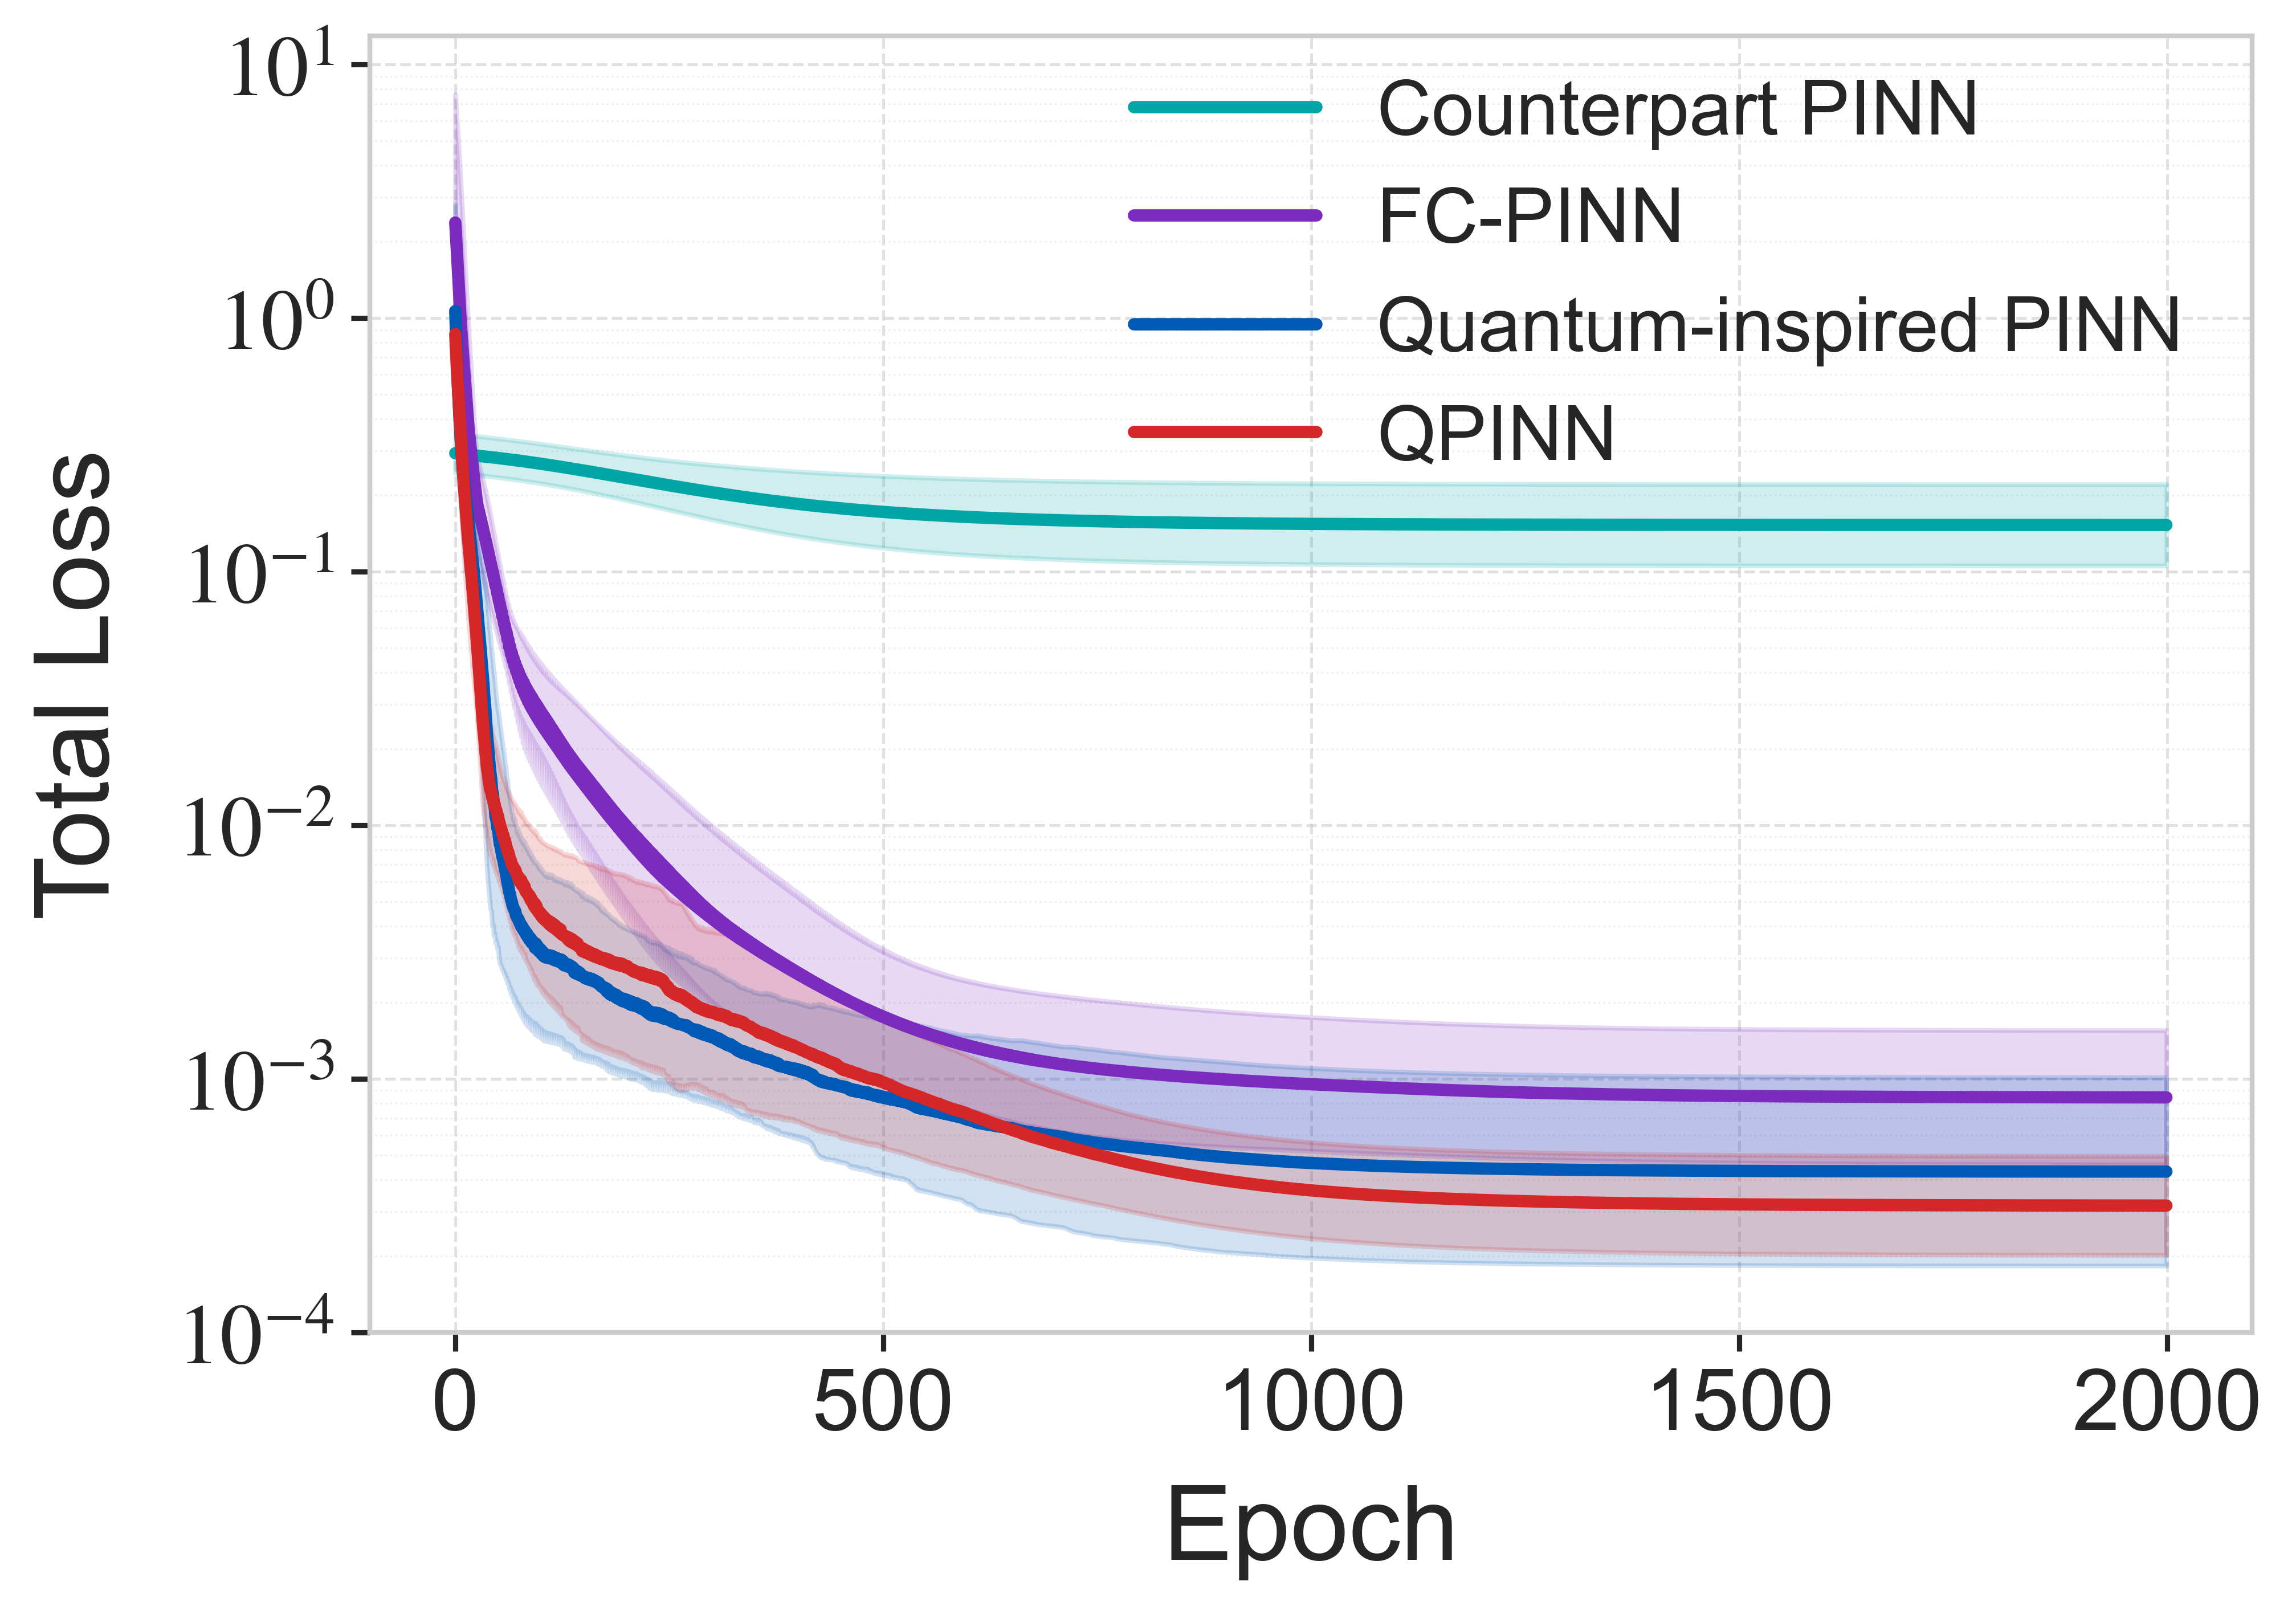

In [39]:
# ====== Adjustable parameters ======
runs = range(10)
# runs = run_indices if "run_indices" in globals() else range(num_runs)
results_dir = results_root if "results_root" in globals() else Path("results_parametric_volatility")

# ====== Load data ======
def load_q_losses(run_idx):
    run_dir = results_dir / f"run_{run_idx}"
    if (run_dir / "losses_qipinn.npy").exists():
        return (
            np.load(run_dir / "losses_qpinn.npy"),
            np.load(run_dir / "losses_qipinn.npy"),
        )
    return (
        np.load(run_dir / "losses_nqpinn.npy"),
        np.load(run_dir / "losses_qpinn.npy"),
    )


losses_pinn = [np.load(results_dir / f"run_{i}" / "losses_pinn.npy") for i in runs]
q_losses = [load_q_losses(i) for i in runs]
losses_qpinn = [qpinn_loss for qpinn_loss, _ in q_losses]
losses_qipinn = [qipinn_loss for _, qipinn_loss in q_losses]
losses_spinn = [np.load(results_dir / f"run_{i}" / "losses_spinn.npy") for i in runs]

losses_pinn = np.array(losses_pinn)
losses_qpinn = np.array(losses_qpinn)
losses_qipinn = np.array(losses_qipinn)
losses_spinn = np.array(losses_spinn)

# ====== Log-space mean and std ======
def log_mean_std(losses):
    log_losses = np.log10(np.clip(losses, 1e-12, None))
    mean_log = np.mean(log_losses, axis=0)
    std_log = np.std(log_losses, axis=0)
    mean_lin = 10 ** mean_log
    lower = 10 ** (mean_log - std_log)
    upper = 10 ** (mean_log + std_log)
    return mean_lin, lower, upper


mean_pinn, lower_pinn, upper_pinn = log_mean_std(losses_pinn)
mean_qipinn, lower_qipinn, upper_qipinn = log_mean_std(losses_qipinn)
mean_qpinn, lower_qpinn, upper_qpinn = log_mean_std(losses_qpinn)
mean_spinn, lower_spinn, upper_spinn = log_mean_std(losses_spinn)

# ====== Plot setup ======
plt.figure(figsize=(7,5), dpi=600)
plt.style.use('seaborn-v0_8-whitegrid')
colors = {
    "SPINN": "#00A6A6",
    "QI PINN": "#005AB5",
    "QPINN": "#d62728",
    "FC-PINN": "#7b2cbf",
}
x = np.arange(len(mean_pinn))


def plot_with_log_std(mean, lower, upper, label, color):
    plt.plot(x, mean, label=label, color=color, linewidth=2.6)
    plt.fill_between(x, lower, upper, color=color, alpha=0.18)


# ====== Plot curves ======
plot_with_log_std(mean_spinn, lower_spinn, upper_spinn, "Counterpart PINN", colors["SPINN"])
plot_with_log_std(mean_pinn, lower_pinn, upper_pinn, "FC-PINN", colors["FC-PINN"])
plot_with_log_std(mean_qipinn, lower_qipinn, upper_qipinn, "Quantum-inspired PINN", colors["QI PINN"])
plot_with_log_std(mean_qpinn, lower_qpinn, upper_qpinn, "QPINN", colors["QPINN"])

ax = plt.gca()
ax.set_yscale("log")
ax.set_ylim(bottom=1e-4)
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=20))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 10)))
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: rf"$10^{{{int(np.log10(y))}}}$" if y > 0 else "")
)
plt.xlabel("Epoch", fontsize=22, labelpad=8)
plt.ylabel("Total Loss", fontsize=22, labelpad=10)
plt.tick_params(axis='both', labelsize=18, width=1.1, length=4)
plt.legend(
    fontsize=16,
    frameon=False,
    framealpha=0.72,
    facecolor='white',
    edgecolor='0.75',
    loc='upper right',
    bbox_to_anchor=(1, 1.02),
    handlelength=2.4,
)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.6)
plt.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_comparison_high_rank.png", bbox_inches="tight")
plt.show()


### Load data of models

In [35]:
# Load data files
load_index = 0
# load_index = run_indices[-1] if "run_indices" in globals() else 8
run_dir = (results_root if "results_root" in globals() else Path("results_parametric_volatility")) / f"run_{load_index}"


def load_state_dict_with_fallback(model, *paths):
    last_error = None
    for path in paths:
        path = Path(path)
        if not path.exists():
            continue
        try:
            model.load_state_dict(torch.load(path, map_location=torch_device))
            return path
        except RuntimeError as exc:
            last_error = exc
    if last_error is not None:
        raise RuntimeError(f"No compatible checkpoint found for {model.__class__.__name__}") from last_error
    raise FileNotFoundError(f"No checkpoint found for {model.__class__.__name__}: {paths}")


pinn_model.to(device=torch_device, dtype=torch_dtype)
qpinn_model.to(device=torch_device, dtype=torch_dtype)
qipinn_model.to(device=torch_device, dtype=torch_dtype)
spinn_model.to(device=torch_device, dtype=torch_dtype)
pinn_model.load_state_dict(torch.load(run_dir / "pinn_model.pt", map_location=torch_device))
load_state_dict_with_fallback(qpinn_model, run_dir / "qpinn_model.pt", run_dir / "nqpinn_model.pt")
load_state_dict_with_fallback(qipinn_model, run_dir / "qipinn_model.pt", run_dir / "qpinn_model.pt")
spinn_model.load_state_dict(torch.load(run_dir / "spinn_model.pt", map_location=torch_device))

# -- Build the grid at a fixed volatility slice --
# s_plot = sigma_ref
s_plot = 0.15
x_vals = np.linspace(0.01, 0.99, 50)
t_vals = np.linspace(0.01, 0.99, 50)
T_grid, X = np.meshgrid(t_vals, x_vals)
S_grid = np.full_like(T_grid, s_plot)

# Analytical solution
Y_true = exact_solution_np(T_grid, X, S_grid)

X_flat = torch.tensor(X.flatten()[:, None], dtype=torch_dtype, device=torch_device)
T_flat = torch.tensor(T_grid.flatten()[:, None], dtype=torch_dtype, device=torch_device)
S_flat = torch.tensor(S_grid.flatten()[:, None], dtype=torch_dtype, device=torch_device)

# QPINN prediction
with torch.no_grad():
    Y_q_flat = qpinn_model(T_flat, X_flat, S_flat).cpu().numpy().flatten()
Y_q = Y_q_flat.reshape(T_grid.shape)

# QIPINN prediction
with torch.no_grad():
    Y_qi_flat = qipinn_model(T_flat, X_flat, S_flat).cpu().numpy().flatten()
Y_qi = Y_qi_flat.reshape(T_grid.shape)

# PINN prediction
with torch.no_grad():
    Y_p_flat = pinn_model(T_flat, X_flat, S_flat).cpu().numpy().flatten()
Y_p = Y_p_flat.reshape(T_grid.shape)

# Counterpart PINN prediction
with torch.no_grad():
    Y_s_flat = spinn_model(T_flat, X_flat, S_flat).cpu().numpy().flatten()
Y_s = Y_s_flat.reshape(T_grid.shape)


### 3D Plot comparison

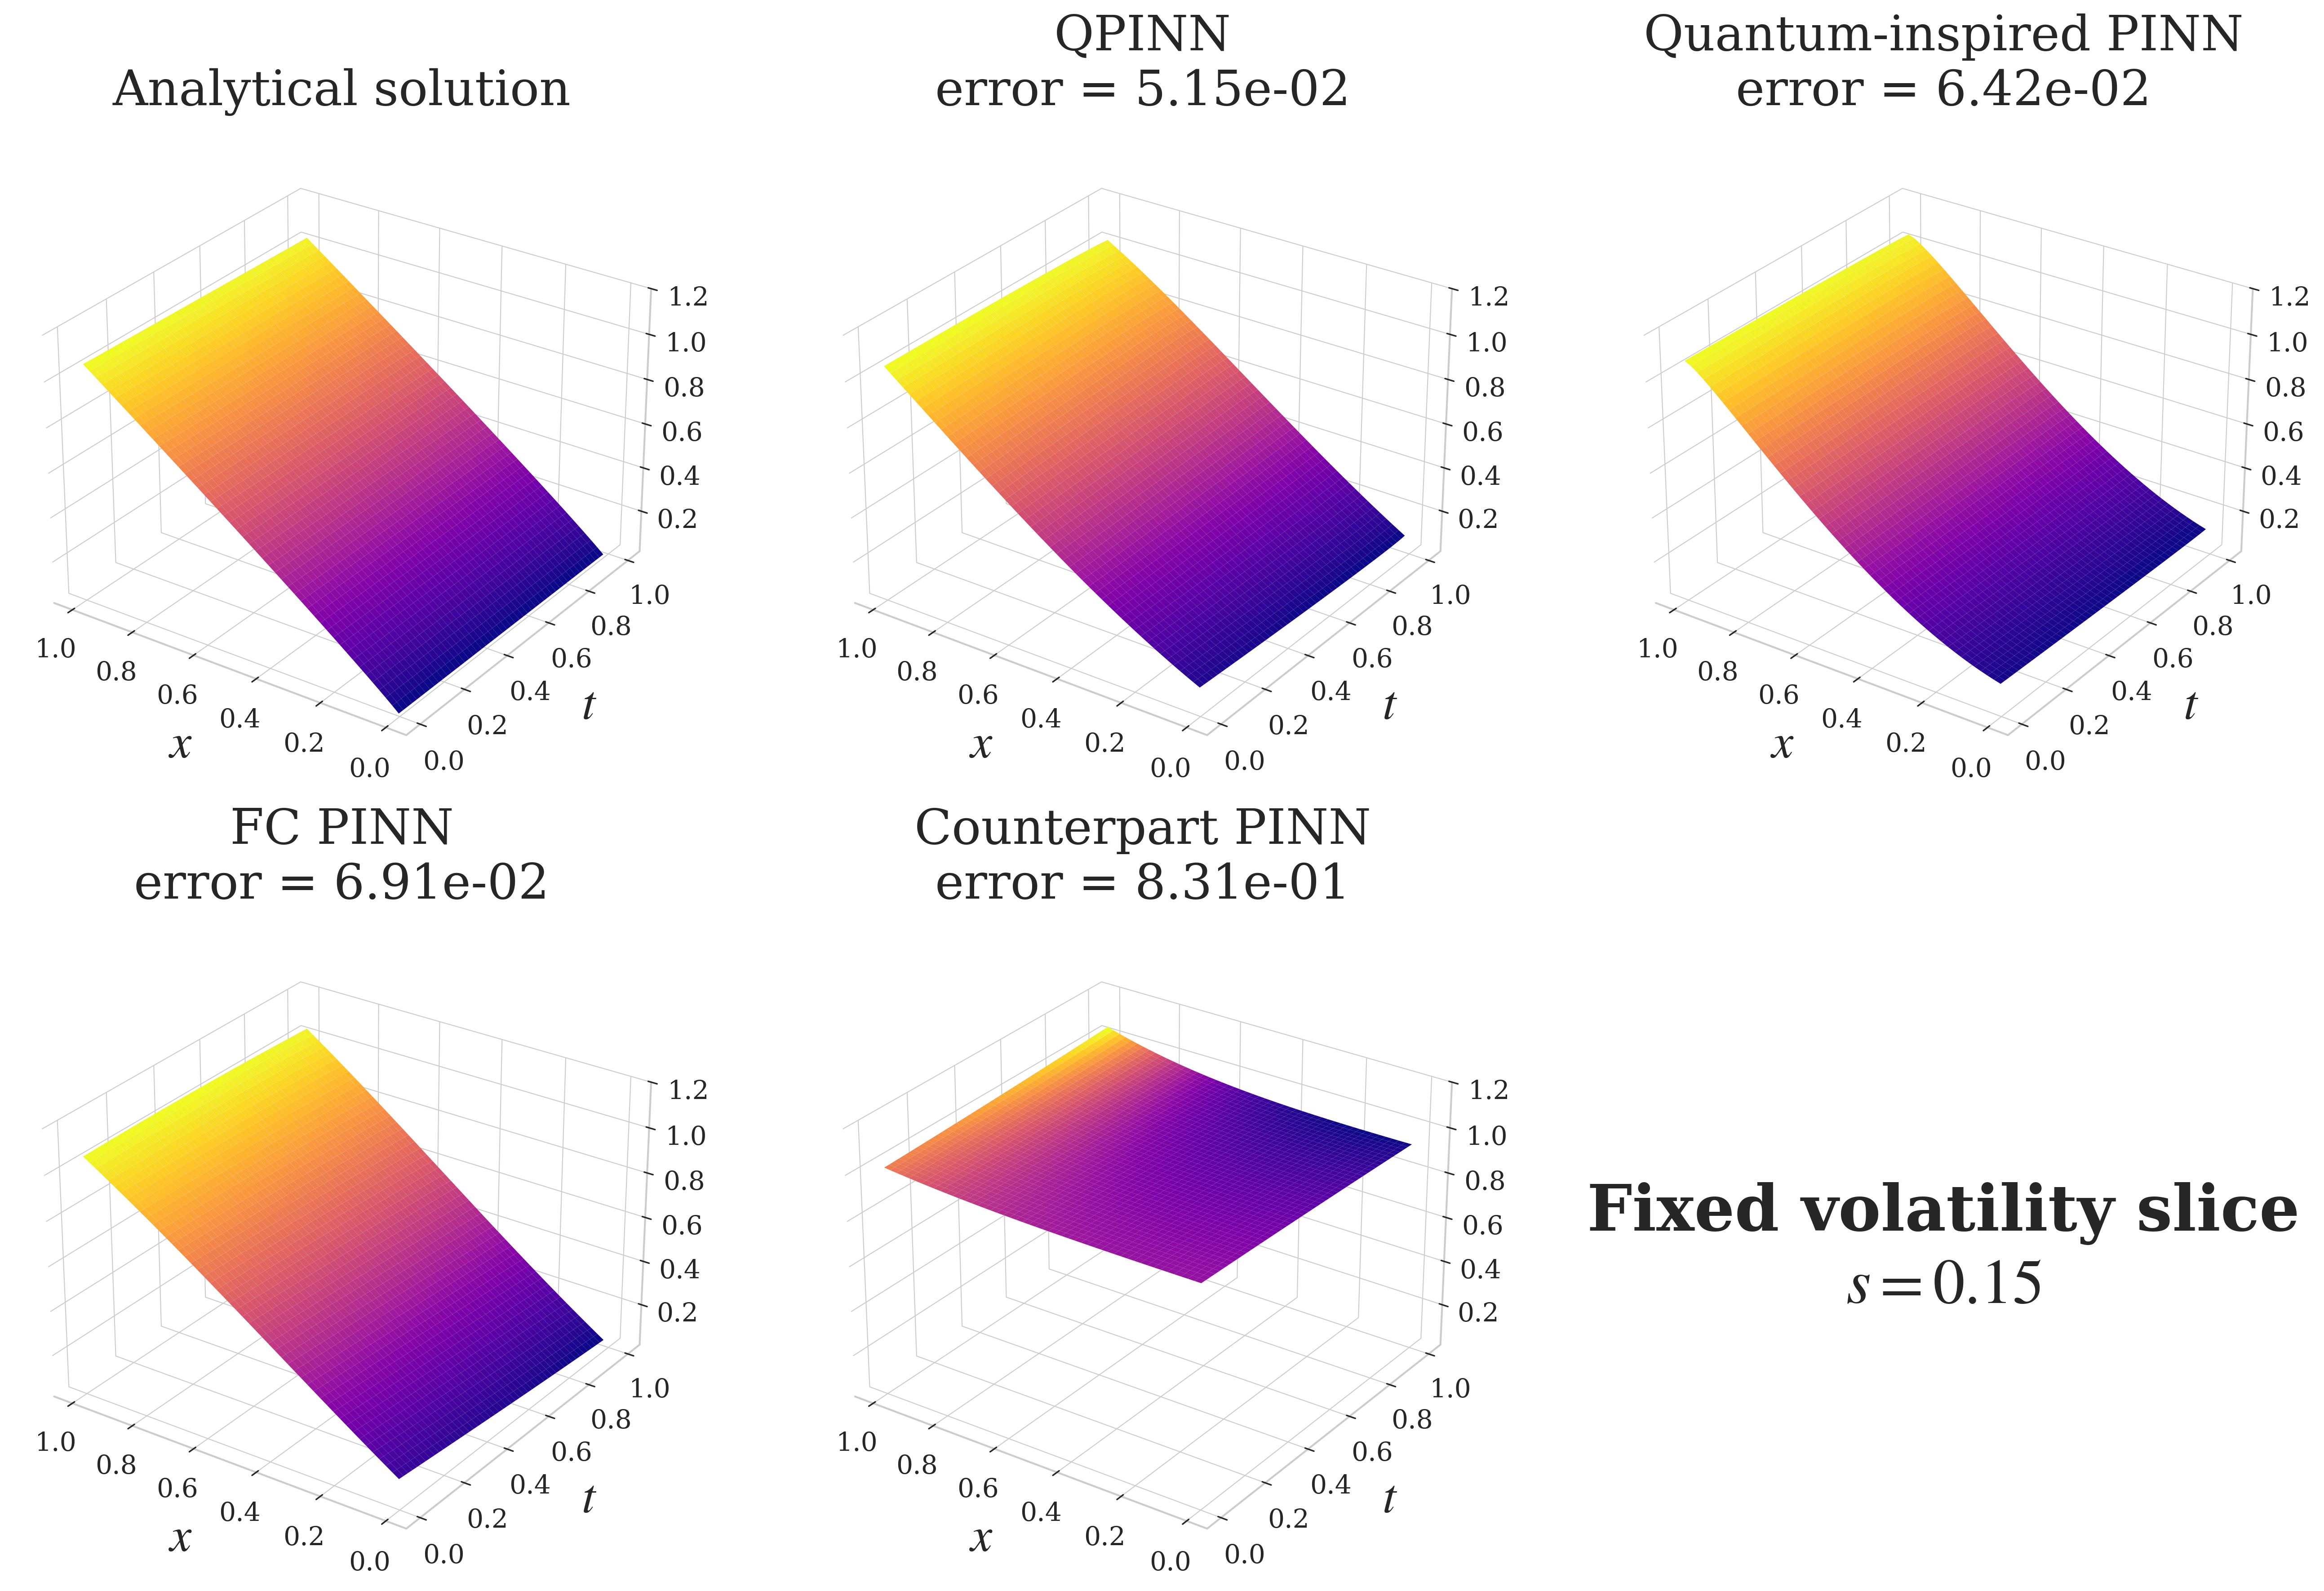

In [36]:
# ---------- simple global style ----------
rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 26,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.titlesize": 26,
    "figure.dpi": 300,
})

# ---------- shared z-range & surface kwargs ----------
ZMIN = np.min([Y_true.min(), Y_q.min(), Y_qi.min(), Y_p.min(), Y_s.min()])
ZMAX = np.max([Y_true.max(), Y_q.max(), Y_qi.max(), Y_p.max(), Y_s.max()])
surf_kwargs = dict(cmap="plasma", edgecolor="none", antialiased=True)


def relative_l2_error(y_pred, y_ref):
    return np.linalg.norm(y_pred - y_ref) / np.linalg.norm(y_ref)


def title_with_error(name, y_pred):
    return f"{name}{chr(10)}error = {relative_l2_error(y_pred, Y_true):.2e}"


def tidy(ax, title, zlab, set_zlim=True):
    ax.view_init(elev=28, azim=-55)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_pane_color((1, 1, 1, 1))
        axis._axinfo["grid"]["linewidth"] = 0.5
    ax.set_title(title, pad=12)
    ax.set_xlabel(r"$x$", labelpad=10)
    ax.set_ylabel(r"$t$", labelpad=10)
    if set_zlim:
        ax.set_zlim(ZMIN, 1.2)
    ax.set_box_aspect((1, 1, 0.7))
    ax.invert_xaxis()


fig = plt.figure(figsize=(18, 12), dpi=300)

ax1 = fig.add_subplot(2, 3, 1, projection="3d")
ax1.plot_surface(X, T_grid, Y_true, **surf_kwargs)
tidy(ax1, r"Analytical solution", r"$f(x,t,s)$")

ax2 = fig.add_subplot(2, 3, 2, projection="3d")
ax2.plot_surface(X, T_grid, Y_q, **surf_kwargs)
tidy(ax2, title_with_error("QPINN", Y_q), r"$v_{\mathrm{QPINN}}(t,x,s)$")

ax3 = fig.add_subplot(2, 3, 3, projection="3d")
ax3.plot_surface(X, T_grid, Y_qi, **surf_kwargs)
tidy(ax3, title_with_error("Quantum-inspired PINN", Y_qi), r"$v_{\mathrm{QI PINN}}(t,x,s)$")

ax4 = fig.add_subplot(2, 3, 4, projection="3d")
ax4.plot_surface(X, T_grid, Y_p, **surf_kwargs)
tidy(ax4, title_with_error("FC PINN", Y_p), r"$v_{\mathrm{PINN}}(t,x,s)$")

ax5 = fig.add_subplot(2, 3, 5, projection="3d")
ax5.plot_surface(X, T_grid, Y_s, **surf_kwargs)
tidy(ax5, title_with_error("Counterpart PINN", Y_s), r"$v_{\mathrm{SPINN}}(t,x,s)$")

ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
ax6.text(
    0.5,
    0.5,
    f"Fixed volatility slice{chr(10)}$s={s_plot:.2f}$",
    ha="center",
    va="center",
    fontsize=34,
    fontweight="semibold",
    transform=ax6.transAxes,
)

plt.tight_layout(pad=1.0, w_pad=1.2, h_pad=1.2)
plt.savefig("3D_comparison_high_rank.png", bbox_inches="tight")
plt.show()



In [ ]:
# ===============================
# Relative L2 error summary across runs
# ===============================
error_runs = list(runs) if "runs" in globals() else list(run_indices)
error_results_dir = results_root if "results_root" in globals() else Path("results_parametric_volatility")

error_order = ("qpinn", "qipinn", "pinn", "spinn")
error_display_names = {
    "qpinn": "QPINN",
    "qipinn": "Quantum-inspired PINN",
    "pinn": "FC PINN",
    "spinn": "Counterpart PINN",
}
model_checkpoint_paths = {
    "pinn": ("pinn_model.pt",),
    "qpinn": ("qpinn_model.pt", "nqpinn_model.pt"),
    "qipinn": ("qipinn_model.pt", "qpinn_model.pt"),
    "spinn": ("spinn_model.pt",),
}


def grid_relative_l2_error(y_pred, y_ref):
    return np.linalg.norm(y_pred - y_ref) / np.linalg.norm(y_ref)


def load_model_for_error(name, run_dir):
    model = build_model(name)
    checkpoint_paths = [run_dir / filename for filename in model_checkpoint_paths[name]]
    load_state_dict_with_fallback(model, *checkpoint_paths)
    model.eval()
    return model


def evaluate_error_on_current_grid(model):
    with torch.no_grad():
        y_pred = model(T_flat, X_flat, S_flat).detach().cpu().numpy().reshape(T_grid.shape)
    return grid_relative_l2_error(y_pred, Y_true)


def mean_std_text(values):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return "nan \\pm nan"
    std = values.std(ddof=1) if values.size > 1 else 0.0
    return f"{values.mean():.2e} \\pm {std:.2e}"


error_values = {name: [] for name in error_order}
evaluated_error_runs = []
skipped_error_runs = []

for run_idx in error_runs:
    run_dir = error_results_dir / f"run_{run_idx}"
    try:
        run_errors = {}
        for name in error_order:
            model = load_model_for_error(name, run_dir)
            run_errors[name] = evaluate_error_on_current_grid(model)
        for name, value in run_errors.items():
            error_values[name].append(value)
        evaluated_error_runs.append(run_idx)
    except (FileNotFoundError, RuntimeError) as exc:
        skipped_error_runs.append((run_idx, str(exc)))

print(f"Relative L2 error summary on fixed volatility slice s={s_plot:.2f}")
print(f"Evaluated runs: {evaluated_error_runs}")
if skipped_error_runs:
    print(f"Skipped runs: {[run_idx for run_idx, _ in skipped_error_runs]}")
for name in error_order:
    print(f"{error_display_names[name]}: {mean_std_text(error_values[name])}")



### Circuit plot

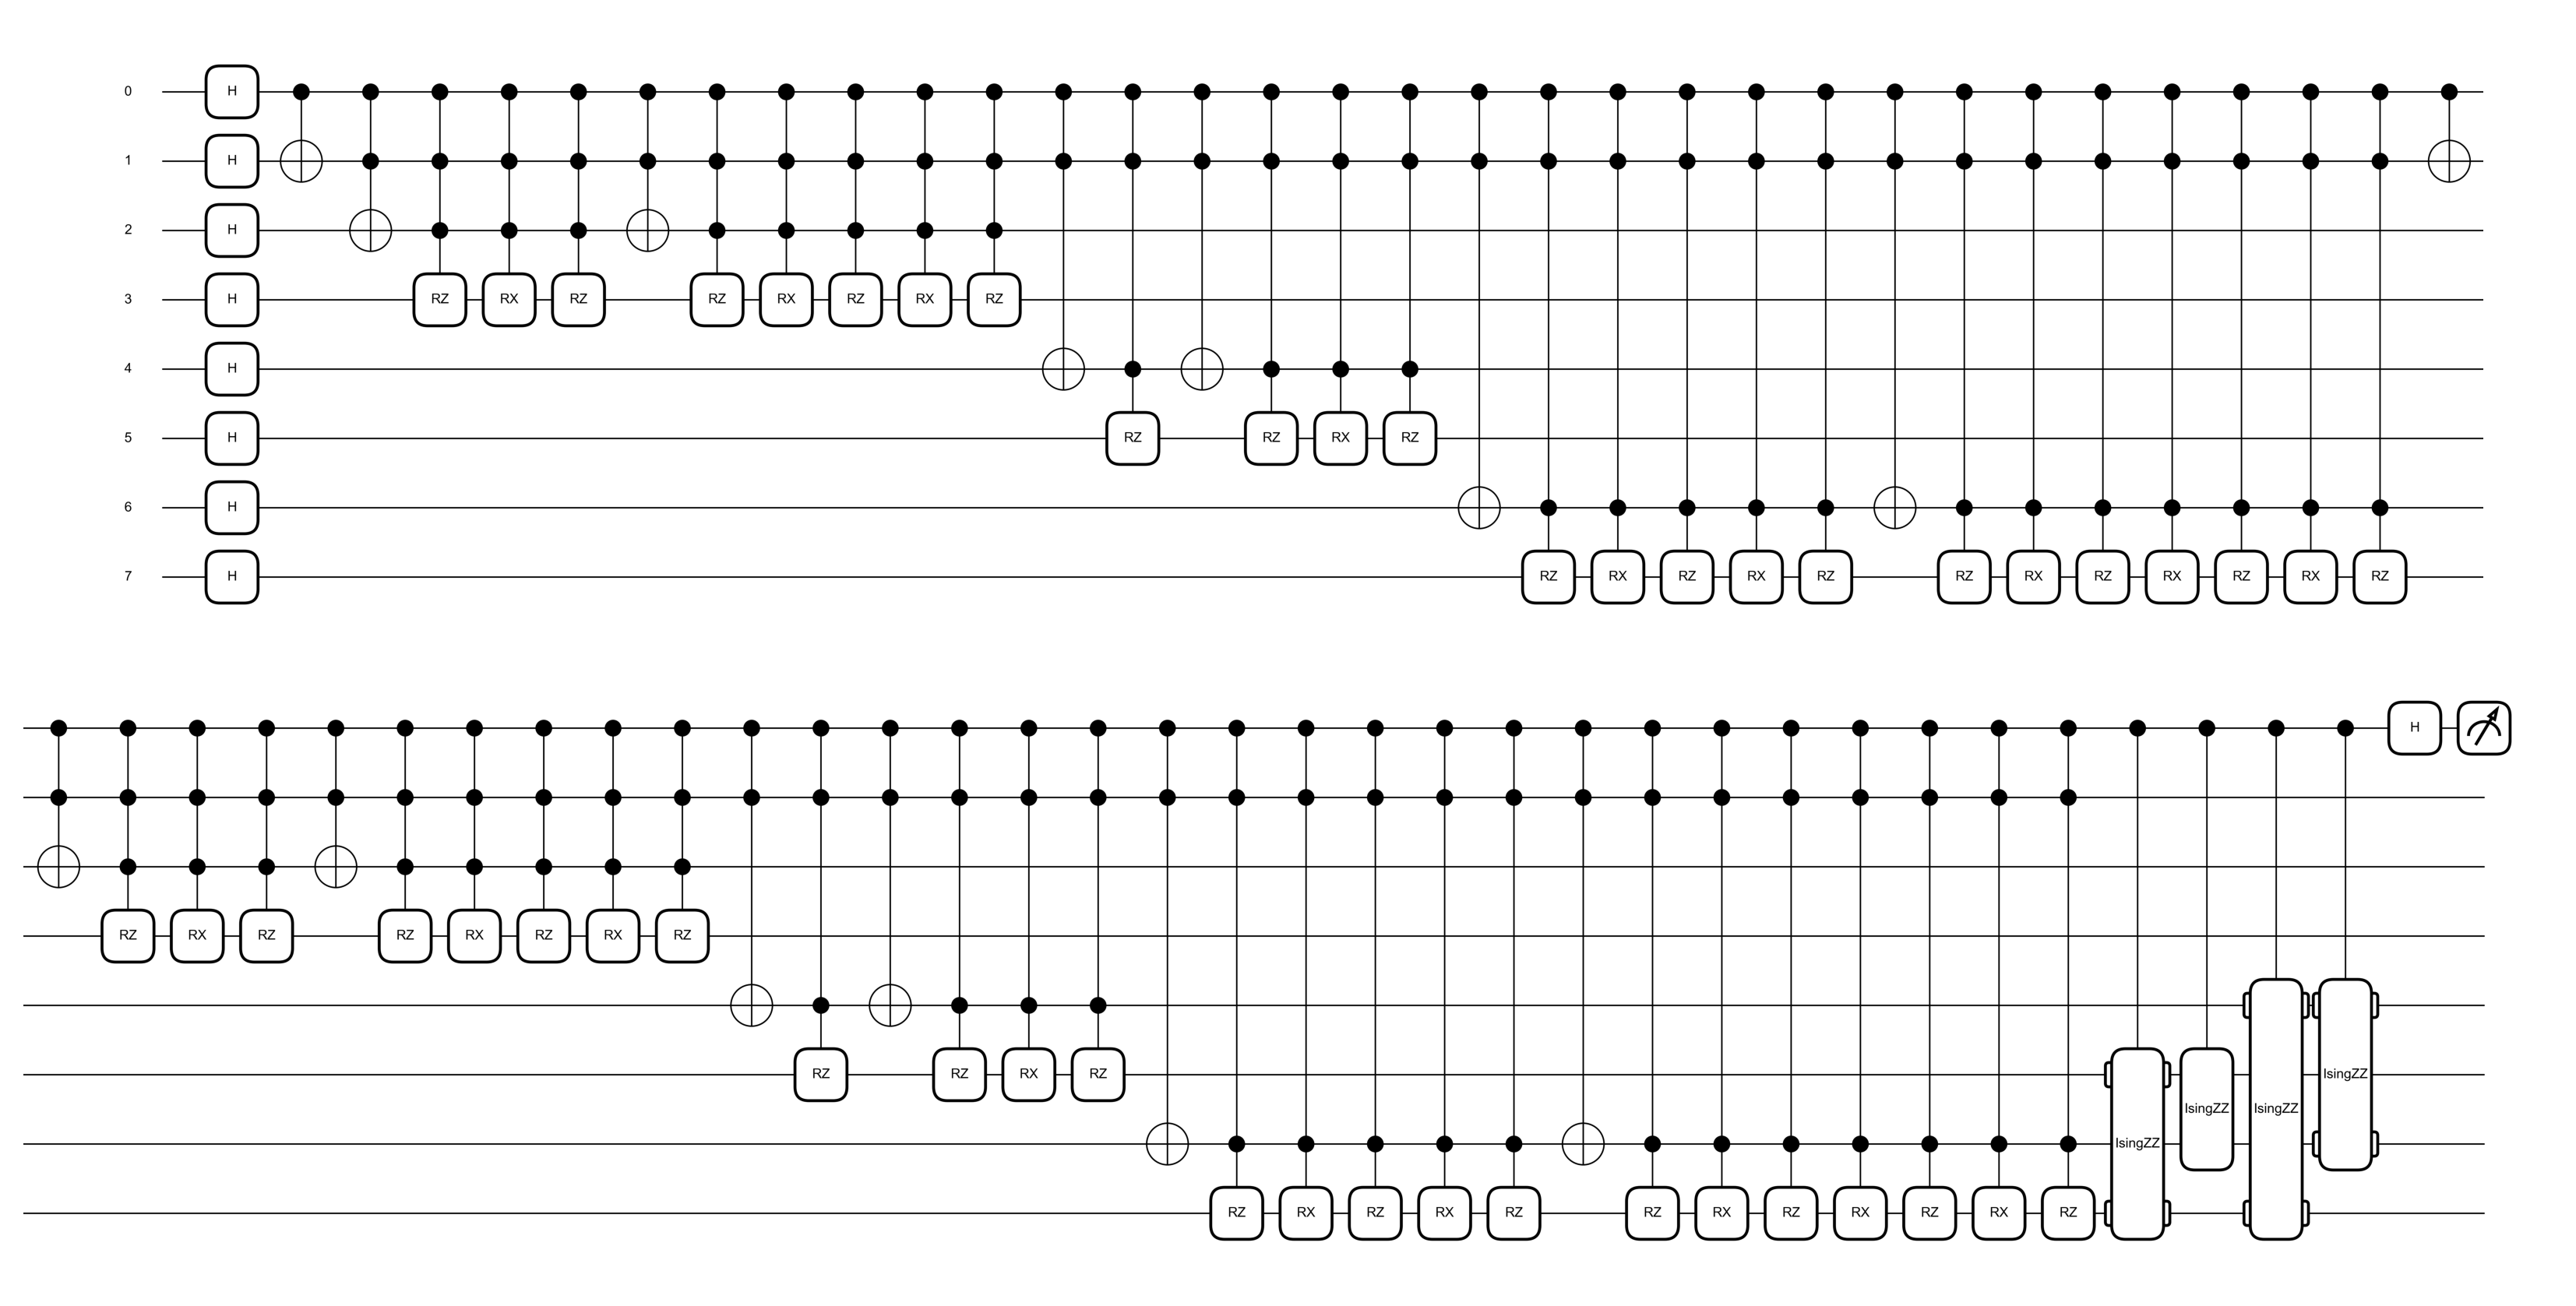

In [40]:
import matplotlib.pyplot as plt
from pennylane import draw_mpl
import numpy as np
import torch

torch.set_default_dtype(torch.float64)

# Draw the rank-2 tensor-decomposed base circuit from Theorem 3.
dtype = torch.float64
t_val = torch.tensor(0.5, dtype=dtype)
x_val = torch.tensor(0.5, dtype=dtype)
s_val = torch.tensor(sigma_ref, dtype=dtype)

ph_x1 = torch.nn.Parameter(torch.rand((2, x_layer1), dtype=dtype))
ph_x2 = torch.nn.Parameter(torch.rand((2, x_layer2), dtype=dtype))
ph_t1 = torch.nn.Parameter(torch.rand((2, t_layer1), dtype=dtype))
ph_t2 = torch.nn.Parameter(torch.rand((2, t_layer2), dtype=dtype))
ph_s1 = torch.nn.Parameter(torch.rand((2, s_layer1), dtype=dtype))
ph_s2 = torch.nn.Parameter(torch.rand((2, s_layer2), dtype=dtype))
theta_list = nn.ParameterList([nn.Parameter(torch.randn((), dtype=dtype)) for _ in range(4)])

p_x1 = ph_x1.detach()
p_x2 = ph_x2.detach()
p_t1 = ph_t1.detach()
p_t2 = ph_t2.detach()
p_s1 = ph_s1.detach()
p_s2 = ph_s2.detach()

# Create the MPL drawer:
mpl_drawer = draw_mpl(f_Wp_qml)

# Draw the circuit once, then wrap the rendered figure into two rows.
fig_full, ax_full = mpl_drawer(t_val, x_val, s_val, p_x1, p_x2, p_t1, p_t2, p_s1, p_s2, theta_list)
fig_full.canvas.draw()
full_image = np.asarray(fig_full.canvas.buffer_rgba()).copy()
plt.close(fig_full)

height, width = full_image.shape[:2]
rgb = full_image[:, :, :3]
ink_density = np.any(rgb < 245, axis=2).mean(axis=0)
window = max(25, width // 200)
smoothed_density = np.convolve(ink_density, np.ones(window) / window, mode="same")
search_start = width // 3
search_stop = 2 * width // 3
split = search_start + int(np.argmin(smoothed_density[search_start:search_stop]))
segments = [
    full_image[:, :split],
    full_image[:, split:],
]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), dpi=300)
for ax, segment in zip(axes, segments):
    ax.imshow(segment)
    ax.axis("off")

fig.subplots_adjust(hspace=0.02)
fig.savefig("qsp_circuit_high_rank.png", dpi=300, bbox_inches="tight")
plt.show()
